## Multivariate GARCH in Tensorflow/Keras

Modelling correlations between SP 500 and DAX 

In [101]:
import yfinance as yf
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import datetime as dt
import tf_keras
import tensorflow_probability as tfp
from curl_cffi import requests

In [5]:
session = requests.Session(impersonate='chrome')
data = yf.download(tickers=['^GDAXI', '^GSPC'], start='2017-09-10', end='2022-09-10', interval='1d', session = session)

[*********************100%***********************]  2 of 2 completed


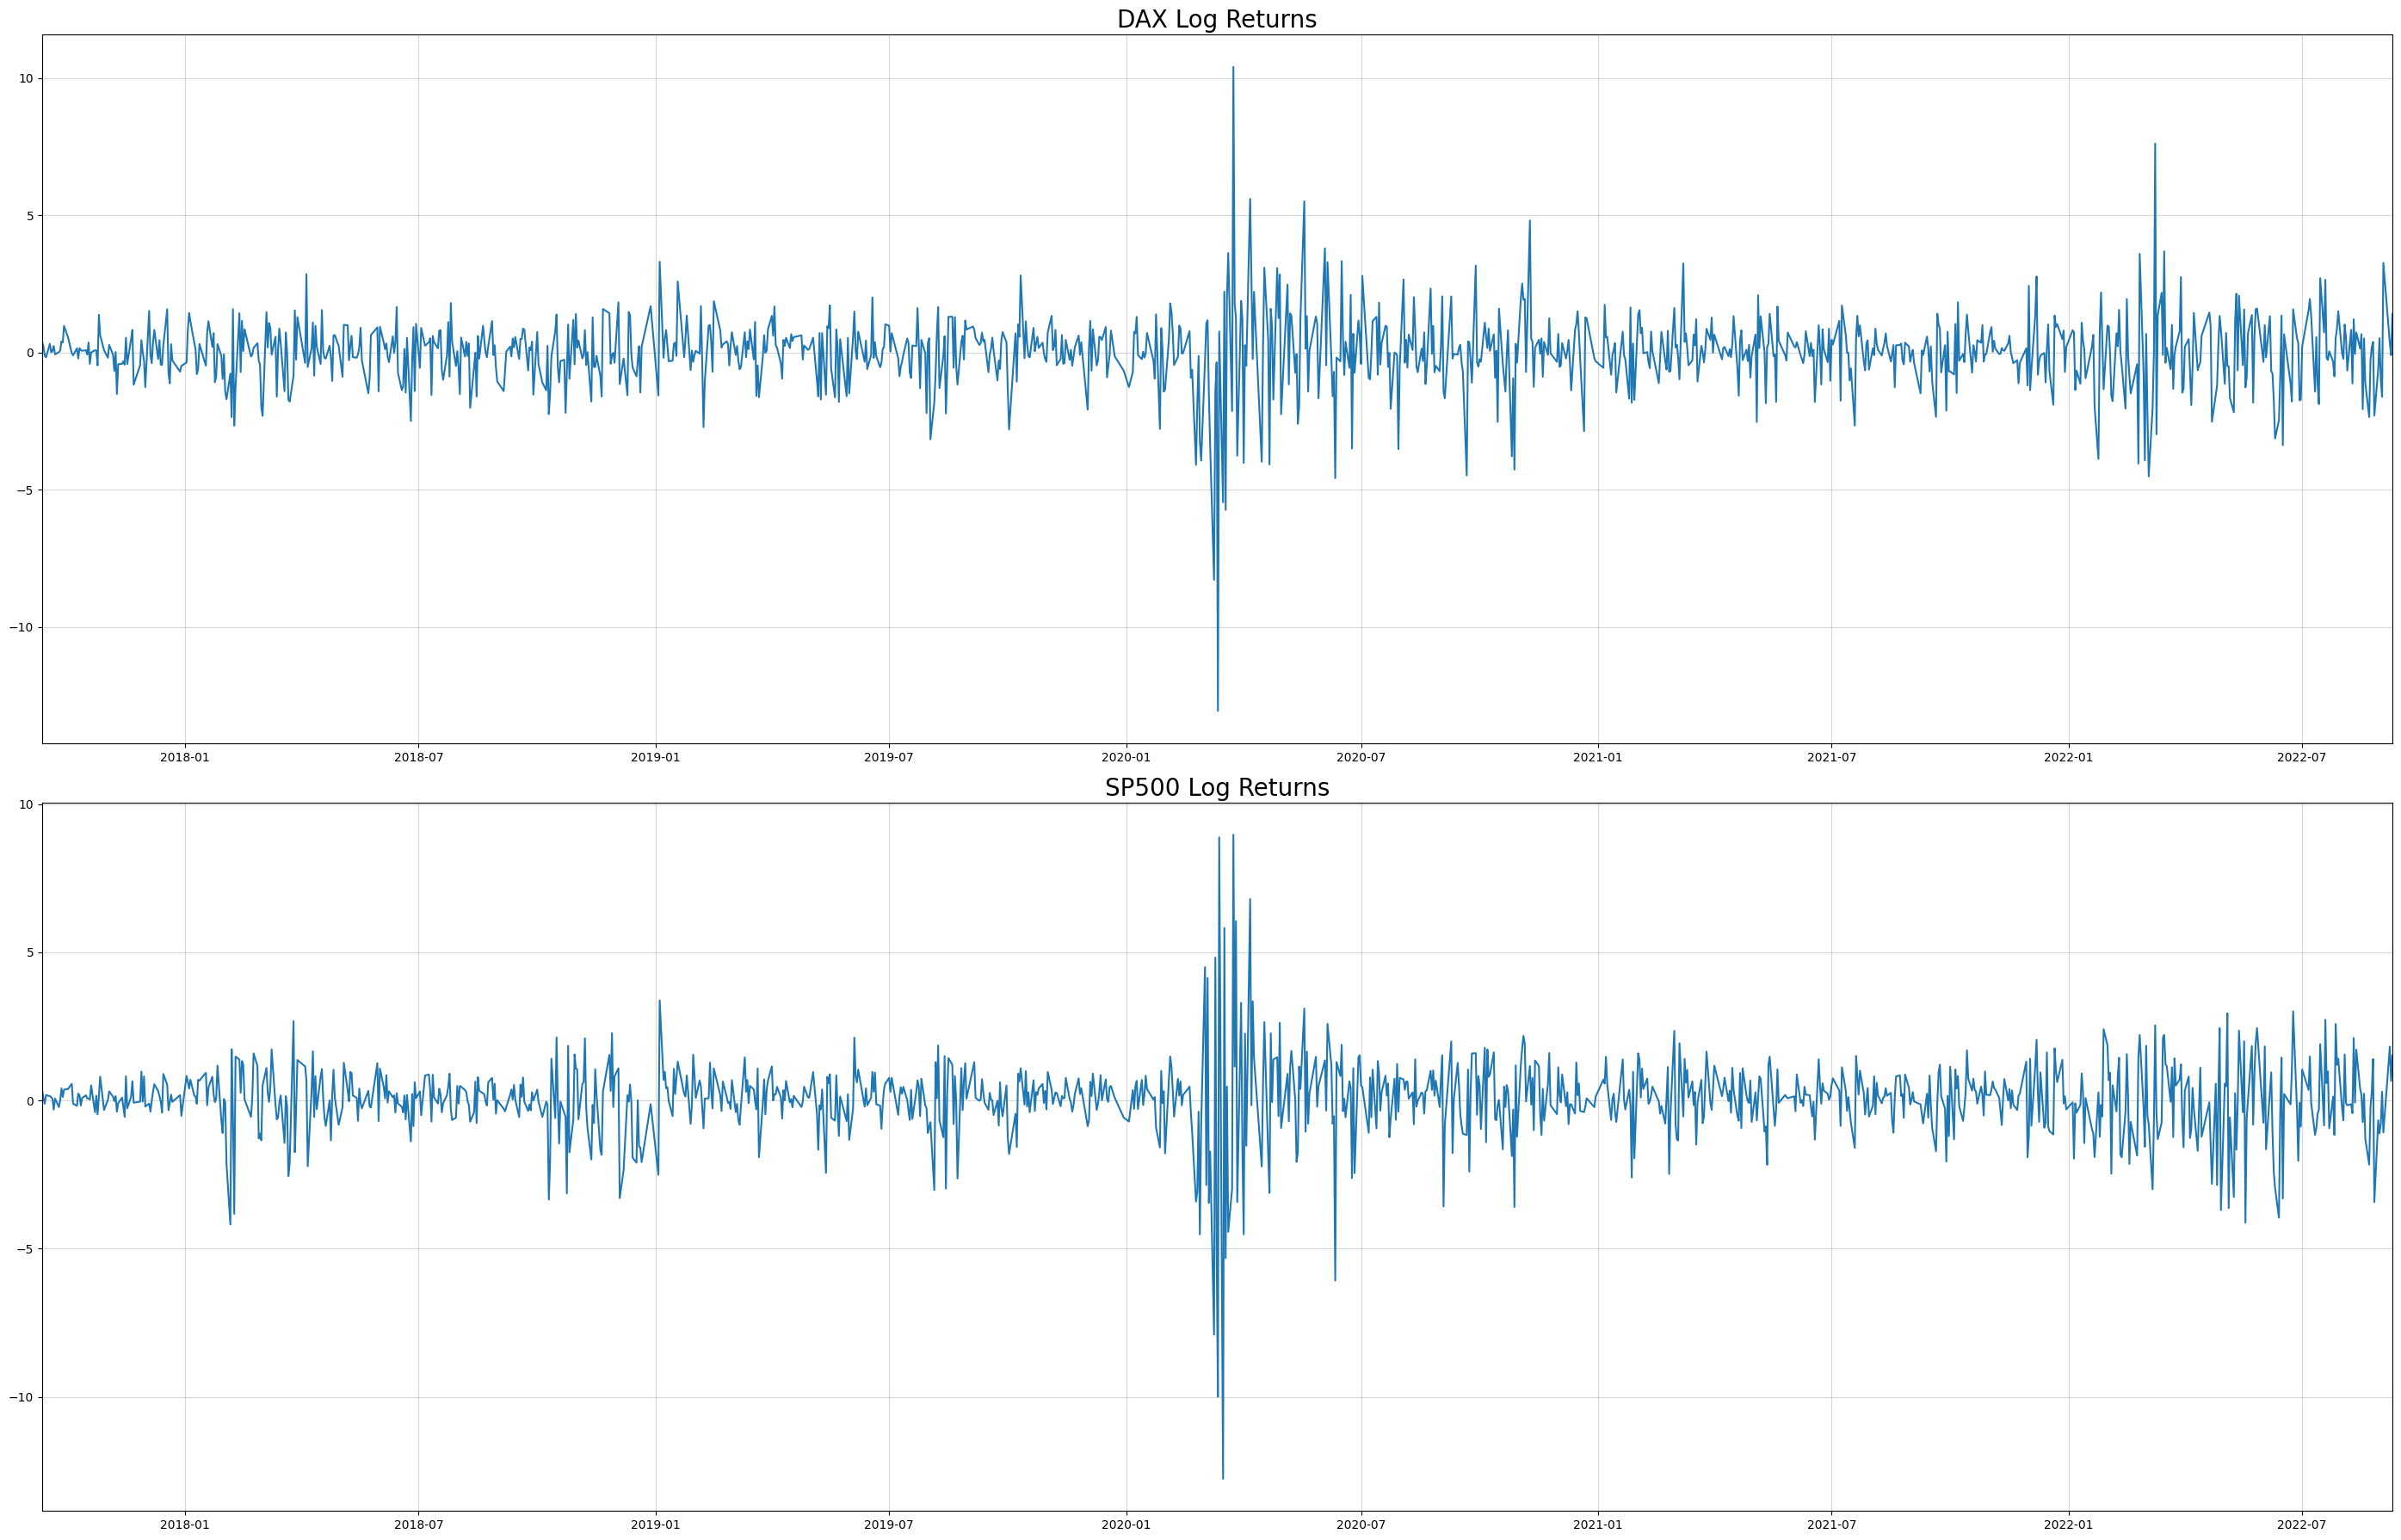

In [102]:
# Preprocessing Data + Initial Visualisations
Close = data['Close']
Close.index = pd.to_datetime(Close.index, format = '%Y-%m-%d')
log_rets = np.log(Close / Close.shift()) * 100
log_rets = log_rets.dropna()
log_rets = log_rets.rename(columns={'^GDAXI': 'DAX', '^GSPC': 'SP500'})

#Plots
fig, axs = plt.subplots(2,1, figsize = (28, 18))

for i, ticker in enumerate(log_rets.columns):
    axs[i].plot(log_rets[ticker], label = ticker)
    axs[i].grid(alpha = 0.5)
    axs[i].margins(x=0)
    axs[i].set_title(f'{log_rets.columns[i]} Log Returns', size = 20)

plt.tight_layout()
plt.show();

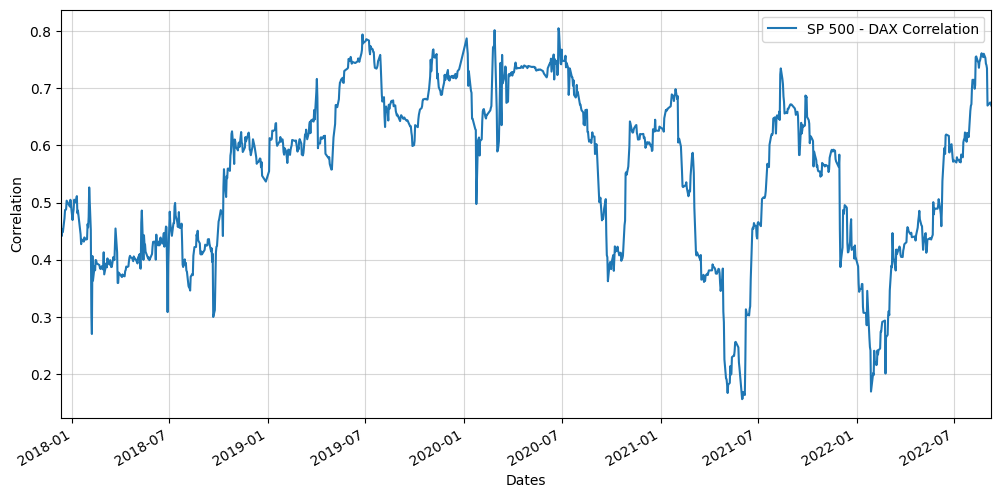

In [103]:
#Plot the Correlations too
Rolling_Correlations = log_rets.rolling(60).corr()
Correlations_SP_DAX = Rolling_Correlations['SP500'][Rolling_Correlations.index.get_level_values(1)=='DAX']

#Plot (start 30 days out - let rolling correlations build up)
fig, axs = plt.subplots(figsize=(12,6))
#Start 30 days out
plt.plot(log_rets.index[30:], Correlations_SP_DAX.values[30:], label = 'Rolling Correlations over 60 days')
plt.xlabel('Dates')
plt.ylabel('Correlation')
plt.gcf().autofmt_xdate()
plt.margins(x=0)
plt.grid(alpha = 0.5)
plt.legend(['SP 500 - DAX Correlation'])


In [104]:
#Keep last 3 months as testing data
test_size = 90
training_data = np.float32(log_rets)[:-test_size, :]
testing_data = np.float32(log_rets)[-test_size:, :]


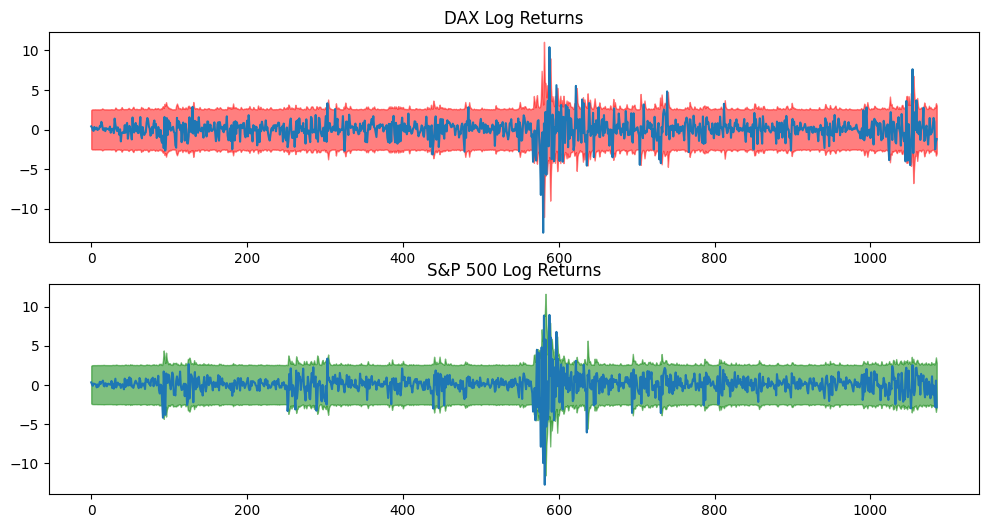

In [156]:
#Training the model
from scipy.stats import norm

model = MGARCH_DCC(training_data)
output = model(training_data)

means = output.mean().numpy()
stds = output.stddev().numpy()

lowers = norm(means, stds).ppf(0.05)
uppers = norm(means, stds).ppf(0.95)

fig, axs = plt.subplots(2,1, figsize=(12,6))
#Plotting DAX
axs[0].set_title('DAX Log Returns')
axs[0].plot(training_data[:, 0])
axs[0].fill_between(np.arange(len(training_data)), lowers[:, 0], uppers[:, 0], color = 'red', alpha = 0.5)

#Plotting SP 500
axs[1].set_title('S&P 500 Log Returns')
axs[1].plot(training_data[:, 1])
axs[1].fill_between(np.arange(len(training_data)), lowers[:, 1], uppers[:, 1], color = 'green', alpha = 0.5)


In [141]:
#Covariance to Correlation takes any covariance matrix into correlations (this is a tensor we have 2 assets)
#Covariance to Correlation Function - takes the covariance matrix ( T x K x K )
correlation_12 = [model.cov_to_corr(output.covariance()[i, :,:])[0,1].numpy() for i in range(len(training_data))]

Text(0.5, 1.0, 'Conditional Correlations')

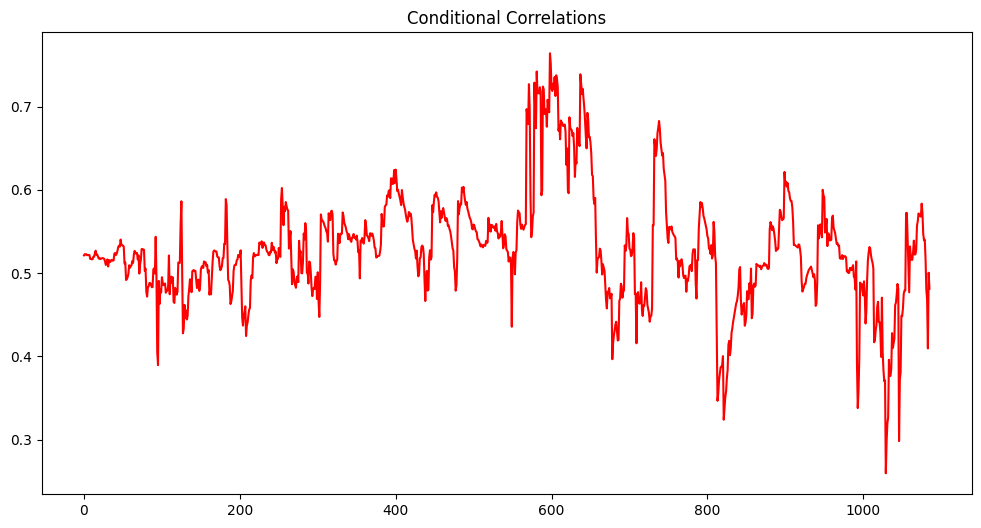

In [142]:
plt.figure(figsize = (12,6))
plt.plot(correlation_12, color='red')
plt.title('Conditional Correlations')

In [148]:
import sys
module_path = r"C:\Users\Phillip\Desktop\Python\Python Notebooks (Mine)\Modules\DCC-GARCH-master"
if module_path not in sys.path:          # keep sys.path tidy
    sys.path.append(module_path)

from DCC_GARCH.GARCH.GARCH import GARCH
from DCC_GARCH.GARCH.GARCH_loss import garch_loss_gen
from DCC_GARCH.DCC.DCC import DCC
from DCC_GARCH.DCC.DCC_loss import dcc_loss_gen

In [157]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-2))

In [158]:
model.fit(training_data, training_data, batch_size=len(training_data), shuffle=False, epochs = 300, verbose= False)

ValueError: not enough values to unpack (expected 2, got 0)

In [139]:
training_data

array([[ 0.39623475,  0.33583027],
       [ 0.2296866 ,  0.07568342],
       [-0.10456768, -0.11013239],
       ...,
       [-2.5159407 , -2.8132076 ],
       [-1.5529273 ,  0.5681765 ],
       [-1.2121974 , -2.855001  ]], dtype=float32)

### GARCH Matrices
Main idea behind DCC-GARCH is to split up the conditional covariance matrix Sigma into matrices conditional standard deviations and conditional correlations : 

$S = DRD$

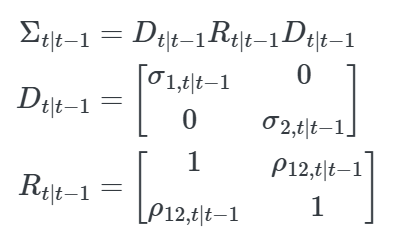

In DCC, we assume the correlations are not constant and are autoregressive. We can break the correlation matrix down  

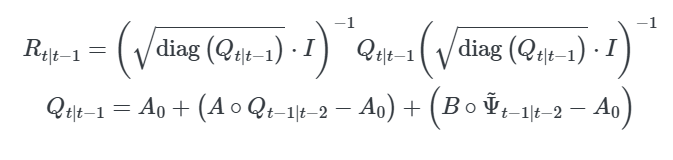

    Q : evolving raw correlations at time t ( K x K for every time step)
    R : proper correlation matrix ( K x K with diagonal = 1)
    D : conditional standard deviations at time t ( K x K for every time step)
    H (or Sigma) : full conditional covariance at time t ( K x K for every time step)
### GARCH Terms

epsilon_t : mean-adjusted innovations

## GARCH Class

In [155]:
class MGARCH_DCC(tf.keras.Model):
    """
    Tensorflow/Keras implementation of multivariate GARCH under dynamic conditional correlation (DCC) specification.
    Further reading:
        - Engle, Robert. "Dynamic conditional correlation: A simple class of multivariate generalized autoregressive conditional heteroskedasticity models."
        - Bollerslev, Tim. "Modeling the Coherence in Short-Run Nominal Exchange Rates: A Multi-variate Generalized ARCH Model."
        - Lütkepohl, Helmut. "New introduction to multiple time series analysis."
    """
    
    def __init__(self, y):
        """
        Args:
            y: NxM numpy.array of N observations of M correlated time-series
        """
        super().__init__()
        n_dims = y.shape[1]
        self.n_dims = n_dims
        
        self.MU = tf.Variable(np.mean(y,0)) #use a mean variable
        
        self.sigma0 = tf.Variable(np.std(y,0)) #initial standard deviations at t=0
        
        #we initialize all restricted parameters to lie inside the desired range
        #by keeping the learning rate low, this should result in admissible results
        #for more complex models, this might not suffice
        self.alpha0 = tf.Variable(np.std(y,0))
        self.alpha = tf.Variable(tf.zeros(shape=(n_dims,))+0.25)
        self.beta = tf.Variable(tf.zeros(shape=(n_dims,))+0.25)
        
        self.L0 = tf.Variable(np.float32(np.linalg.cholesky(np.corrcoef(y.T)))) #decomposition of A_0
        self.A = tf.Variable(tf.zeros(shape=(1,))+0.9)
        self.B = tf.Variable(tf.zeros(shape=(1,))+0.05)
        
           
    def call(self, y):
        """
        Args:
            y: NxM numpy.array of N observations of M correlated time-series
        """
        return self.get_conditional_dists(y)
    
    
    def get_log_probs(self, y):
        """
        Calculate log probabilities for a given matrix of time-series observations
        Args:
            y: NxM numpy.array of N observations of M correlated time-series
        """
        return self.get_conditional_dists(y).log_prob(y)
    
        
    @tf.function
    def get_conditional_dists(self, y):
        """
        Calculate conditional distributions for given observations
        Args:
            y: NxM numpy.array of N observations of M correlated time-series
        """
        T = tf.shape(y)[0]
        
        #create containers for looping
        mus = tf.TensorArray(tf.float32, size = T) #observation mean container
        Sigmas = tf.TensorArray(tf.float32, size = T) #observation covariance container

        
        sigmas = tf.TensorArray(tf.float32, size = T+1)
        us = tf.TensorArray(tf.float32, size = T+1)
        Qs = tf.TensorArray(tf.float32, size = T+1)
        
        
        #initialize respective values for t=0
        sigmas = sigmas.write(0, self.sigma0)
        A0 = tf.transpose(self.L0)@self.L0
        Qs = Qs.write(0, A0) #set initial unnormalized correlation equal to mean matrix
        us = us.write(0, tf.zeros(shape=(self.n_dims,))) #initial observations equal to zero
        
        
        #convenience
        sigma0 = self.sigma0
        alpha0 = self.alpha0**2 #ensure positivity
        alpha = self.alpha
        beta = self.beta

        A = self.A
        B = self.B
        
        
        for t in tf.range(T):
            #tm1 = 't minus 1'
            #suppress conditioning on past in notation
            
            #1) calculate conditional standard deviations
            u_tm1 = us.read(t) 
            sigma_tm1 = sigmas.read(t)
            
            sigma_t = (alpha0 + alpha*sigma_tm1**2 + beta*u_tm1**2)**0.5
            
            #2) calculate conditional correlations
            u_tm1_standardized = u_tm1/sigma_tm1
                   
            Psi_tilde_tm1 = tf.reshape(u_tm1_standardized, (self.n_dims,1))@tf.reshape(u_tm1_standardized, (1,self.n_dims))

            Q_tm1 = Qs.read(t)
            Q_t = A0 + A*(Q_tm1 - A0) + B*(Psi_tilde_tm1 - A0)
            R_t = self.cov_to_corr(Q_t)
            
            #3) calculate conditional covariance
            D_t = tf.linalg.LinearOperatorDiag(sigma_t)
            Sigma_t = D_t@R_t@D_t
              
            
            #4) store values for next iteration
            sigmas = sigmas.write(t+1, sigma_t)
            us = us.write(t+1, y[t,:]-self.MU) #we want to model the zero-mean disturbances
            Qs = Qs.write(t+1, Q_t)
            
            mus = mus.write(t, self.MU)
            Sigmas = Sigmas.write(t, Sigma_t)
            
        return tfp.distributions.MultivariateNormalFullCovariance(mus.stack(), Sigmas.stack())
    
    
    def cov_to_corr(self, S):
        """
        Transforms covariance matrix to a correlation matrix via matrix operations
        Args:
            S: Symmetric, positive semidefinite covariance matrix (tf.Tensor)
        """
        D = tf.linalg.LinearOperatorDiag(1/(tf.linalg.diag_part(S)**0.5))
        return D@S@D
        
    

    def train_step(self, data):
        """
        Custom training step to handle keras model.fit given that there is no input-output structure in our model
        Args:
            S: Symmetric, positive semidefinite covariance matrix (tf.Tensor)
        """
        x,y = data
        with tf.GradientTape() as tape:
            loss = -tf.math.reduce_mean(self.get_log_probs(y))
            
        trainable_vars = self.trainable_weights
        gradients = tape.gradient(loss, trainable_vars)
        
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))
        
        return {"Current loss": loss}
    
    
    
    def sample_forecast(self, y, T_forecast = 30, n_samples=500):
        """
        Create forecast samples to use for monte-carlo simulation of quantities of interest about the forecast (e.g. mean, var, corr, etc.)
        WARNING: This is not optimized very much and can take some time to run, probably due to Python's slow loops - can likely be improved
        Args:
            y: numpy.array of training data, used to initialize the forecast values
            T_forecast: number of periods to predict (integer)
            n_samples: Number of samples to draw (integer)
        """
        T = tf.shape(y)[0]
        
        #create lists for looping; no gradients, thus no tf.TensorArrays needed
        #can initialize directly
        mus = []
        Sigmas = []

        us = [tf.zeros(shape=(self.n_dims,))]
        sigmas = [self.sigma0]        
        Qs = []
        
        #initialize remaining values for t=0
        A0 = tf.transpose(self.L0)@self.L0
        Qs.append(A0)
        
        
        #convenience
        sigma0 = self.sigma0 
        alpha0 = self.alpha0**2 #ensure positivity
        alpha = self.alpha
        beta = self.beta

        A = self.A
        B = self.B
        
        #'warmup' to initialize latest lagged features
        for t in range(T):
            #tm1 = 't minus 1'
            #suppress conditioning on past in notation
            u_tm1 = us[-1]
            sigma_tm1 = sigmas[-1]
            
            sigma_t = (alpha0 + alpha*sigma_tm1**2 + beta*u_tm1**2)**0.5
            
            u_tm1_standardized = u_tm1/sigma_tm1
            
            Psi_tilde_tm1 = tf.reshape(u_tm1_standardized, (self.n_dims,1))@tf.reshape(u_tm1_standardized, (1,self.n_dims))

            Q_tm1 = Qs[-1]
            Q_t = A0 + A*(Q_tm1 - A0) + B*(Psi_tilde_tm1 - A0)
            R_t = self.cov_to_corr(Q_t)
            
            D_t = tf.linalg.LinearOperatorDiag(sigma_t)
            Sigma_t = D_t@R_t@D_t
              
            
            sigmas.append(sigma_t)
            us.append(y[t,:]-self.MU) #we want to model the zero-mean disturbances
            Qs.append(Q_t)
            
            mus.append(self.MU)
            Sigmas.append(Sigma_t)
  
            
        #sample containers
        y_samples = []
        R_samples = []
        sigma_samples = []
        
        
        for n in range(n_samples):
            
            mus_samp = []
            Sigmas_samp = []

            sigmas_samp = [sigmas[-1]]
            us_samp = [us[-1]]
            Qs_samp = [Qs[-1]]
            
            #forecast containers
            ys_samp = []
            sig_samp = []
            R_samp = [] 
            
            
            for t in range(T_forecast):
                u_tm1 = us_samp[-1]
                sigma_tm1 = sigmas_samp[-1]

                sigma_t = (alpha0 + alpha**2 + beta*u_tm1**2)**0.5

                u_tm1_standardized = u_tm1/sigma_tm1
                
                Psi_tilde_tm1 = tf.reshape(u_tm1_standardized, (self.n_dims,1))@tf.reshape(u_tm1_standardized, (1,self.n_dims))

                Q_tm1 = Qs_samp[-1]
                Q_t = A0 + A*(Q_tm1 - A0) + B*(Psi_tilde_tm1 - A0)
                R_t = self.cov_to_corr(Q_t)

                D_t = tf.linalg.LinearOperatorDiag(sigma_t)
                Sigma_t = D_t@R_t@D_t


                sigmas_samp.append(sigma_t)
                Qs_samp.append(Q_t)
                
                ynext = tfp.distributions.MultivariateNormalFullCovariance(self.MU, Sigma_t).sample()
                ys_samp.append(tf.reshape(ynext,(1,1,-1)))
                sig_samp.append(tf.reshape(sigma_t,(1,1,-1)))
                R_samp.append(tf.reshape(R_t,(1,1,self.n_dims,self.n_dims)))
                
                us_samp.append(ynext-self.MU)
                
            y_samples.append(tf.concat(ys_samp,1))
            R_samples.append(tf.concat(R_samp,1))
            sigma_samples.append(tf.concat(sig_samp,1))
        
        return tf.concat(y_samples,0).numpy(), tf.concat(R_samples,0).numpy(), tf.concat(sigma_samples,0).numpy()